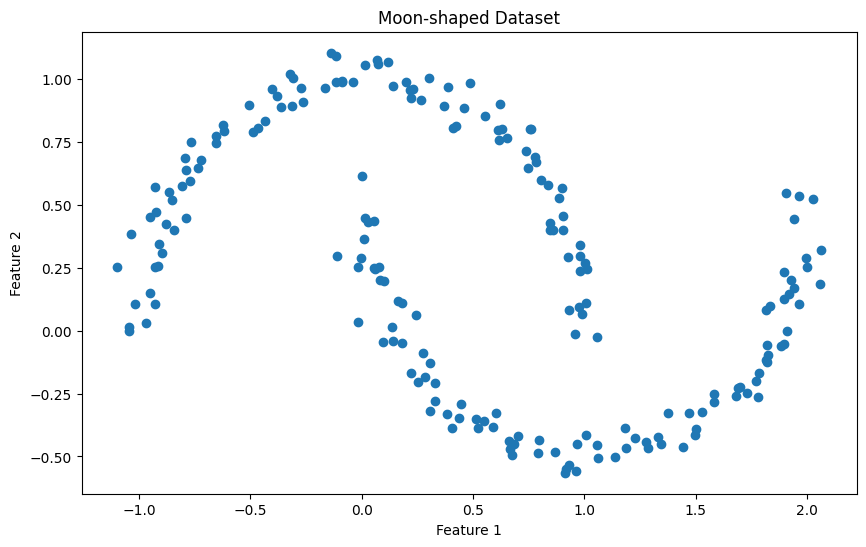

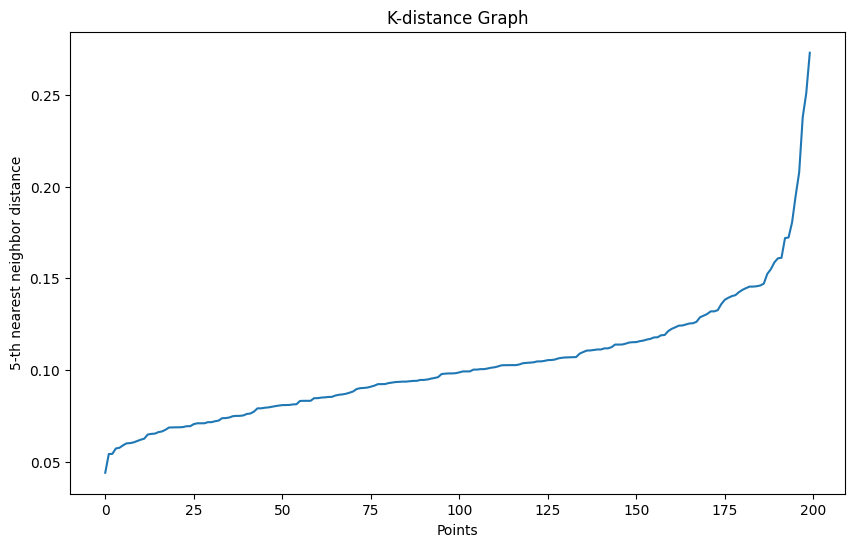

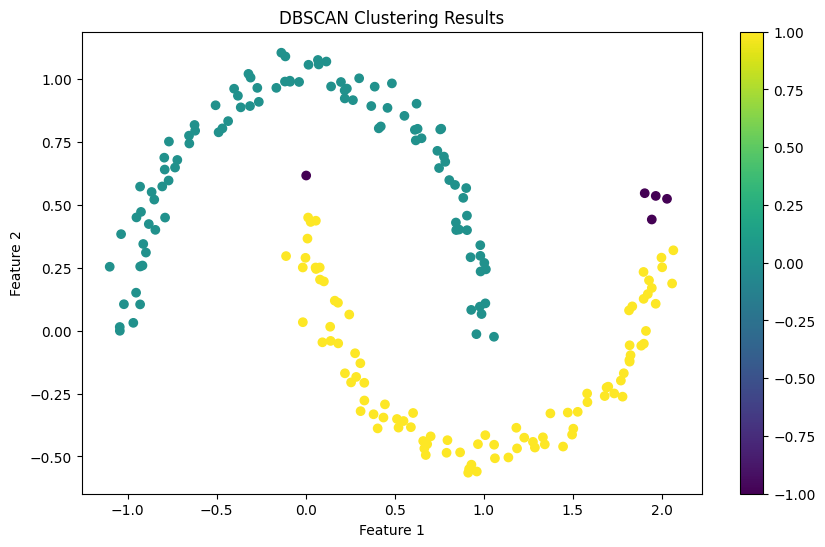

Number of clusters: 2
Number of noise points: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt #to create visualization
from sklearn.datasets import make_moons #Create a synthetic data set for our application as it has pre loaded dataset
from sklearn.cluster import DBSCAN #for density based clustering
from sklearn.neighbors import NearestNeighbors #find nearest neighbour of a point
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42) #generate the sample data,using make moons function which contains 2 dimensional data set,add noise to make it less perfectly structured,x,x_returns feature matrix and the targert vector
# Visualize the dataset
plt.figure(figsize=(10, 6)) #creates a new figure with a size of 10 inches by six inches
plt.scatter(X[:, 0], X[:, 1]) #0 and 1 represent first and second columns of the data set
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show() #displays the plot
# Function to plot k-distance graph
def plot_k_distance_graph(X, k): #calculates the distance to the k-th nearest neighbor for each point,x is dataset and k is number of neighbours
    neigh = NearestNeighbors(n_neighbors=k) #Initializes the NearestNeighbors model to find the k-nearest neighbors.
    neigh.fit(X) #Fits the model using the dataset X.
    distances, _ = neigh.kneighbors(X) #Computes the distances to the k-nearest neighbors for each point in X.
    distances = np.sort(distances[:, k-1]) #sorts the distances to the k-th nearest neighbor for each point in ascending order
    plt.figure(figsize=(10, 6))
    plt.plot(distances) #Plots the sorted distances.
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5) #this calls the function with X as the dataset and k=5, meaning it will plot the distances to the 5th nearest neighbor for each point in X
# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples) #Creates a DBSCAN clustering object with the specified epsilon and min_samples.
clusters = dbscan.fit_predict(X) #Fits the DBSCAN model to the dataset X and returns the cluster labels for each point in X.
# Visualize the results
plt.figure(figsize=(10, 6)) #Creates a new figure with a specified size (10 inches by 6 inches).
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis') #Plots a scatter plot of the data points.
# X[:, 0] and X[:, 1] are the first and second features of the dataset. c=clusters colors the points based on their cluster assignments. cmap
plt.colorbar(scatter) #Adds a color bar to the plot to indicate the cluster colors.
plt.title('DBSCAN Clustering Results') #Sets the title of the plot.
plt.xlabel('Feature 1') #Label the x-axis and y-axis.
plt.ylabel('Feature 2')
plt.show()#Displays the plot.
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0) #creates a set of unique cluster labels.len(set(clusters)) counts these unique labels.
#- (1 if -1 in clusters else 0) adjusts the count by subtracting 1 if there is a -1 label, which typically represents noise points.
n_noise = list(clusters).count(-1) #counts how many times -1 appears in the clusters list, representing the number of noise points.
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

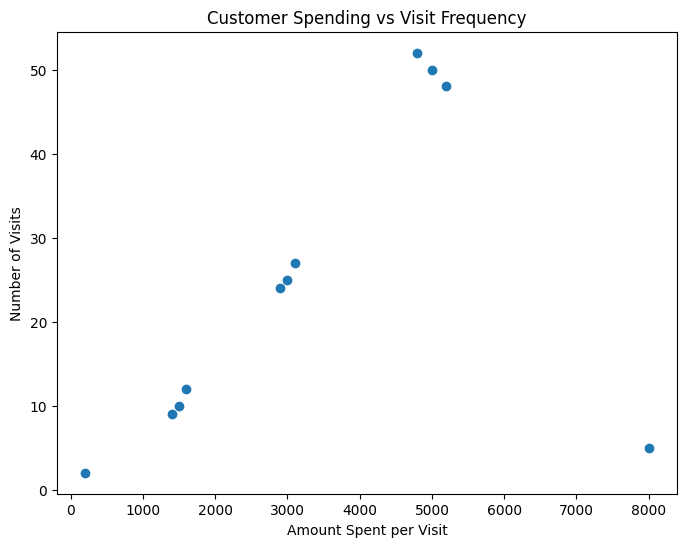

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
# Customer dataset: [Money Spent per Visit, Number of Visits]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])
# Visualize the customer data
plt.figure(figsize=(8,6))
plt.scatter(data[:,0], data[:,1])
plt.title("Customer Spending vs Visit Frequency")
plt.xlabel("Amount Spent per Visit")
plt.ylabel("Number of Visits")
plt.show()




In [ ]:
#Fine tuning a pretrained model
# Scenario: Fine-tune ResNet-50 pretrained on ImageNet
#  to classify 5 types of plant disease from 3,000 leaf images.

# Import PyTorch main library
# PyTorch is used for building and training deep learning models
import torch

# Import torchvision which contains datasets, pretrained models and image
#  utilities
import torchvision

# Import neural network module from PyTorch
# nn contains layers like Linear, Conv2D, ReLU etc.
import torch.nn as nn

# Import pretrained models and image transformations
from torchvision import models, transforms

# Import DataLoader to load dataset in batches
from torch.utils.data import DataLoader

# Import ImageFolder dataset loader
# This loads images arranged in folder structure
# Example:
# dataset/
#     disease1/
#     disease2/
#     disease3/
from torchvision.datasets import ImageFolder


# ---------------------------------------------------------
# STEP 1 : Load a Pretrained ResNet-50 Model
# ---------------------------------------------------------


# ResNet50 is a deep CNN with 50 layers designed by Microsoft
# It is trained on ImageNet dataset (~1.2 million images, 1000 classes)


# Using pretrained weights helps the model already know
# basic visual features like edges, shapes, textures etc.

model = models.resnet50(weights='IMAGENET1K_V2')

# weights='IMAGENET1K_V2'
# loads pretrained weights trained on ImageNet
# This technique is called TRANSFER LEARNING

# Instead of training from scratch,
# we reuse knowledge learned from a huge dataset.


# ---------------------------------------------------------
# STEP 2 : Freeze ALL layers
# ---------------------------------------------------------

# Freezing means we stop updating weights during training

# Why freeze?
# Because the early layers already learned useful
# general visual features like:
# edges
# corners
# textures
# patterns

# We only want to train the final layers for our dataset.

for param in model.parameters():
    param.requires_grad = False

# requires_grad = False means:
# PyTorch will NOT compute gradients for these parameters
# during backpropagation.

# Result:
# The pretrained weights stay unchanged.


# ---------------------------------------------------------
# STEP 3 : Replace the classifier head (Fully Connected layer)
# ---------------------------------------------------------

# ResNet originally outputs 1000 classes (ImageNet classes)
# But our plant disease dataset has only 5 classes.

num_classes = 5

# The final layer of ResNet is:
# model.fc

# We replace it with a custom classifier.

model.fc = nn.Sequential(

    # Dropout randomly disables neurons during training
    # Helps reduce overfitting
    nn.Dropout(0.4),

    # First fully connected layer
    # model.fc.in_features gives the number of input features
    # from the previous ResNet layer (usually 2048)

    nn.Linear(model.fc.in_features, 256),

    # ReLU activation introduces non-linearity
    # Helps model learn complex patterns
    nn.ReLU(),

    # Final layer outputs probabilities for each class
    nn.Linear(256, num_classes)
)

# Architecture of new classifier:
#
# Feature Vector (2048)
#        ↓
#     Dropout
#        ↓
#   Linear (2048 → 256)
#        ↓
#       ReLU
#        ↓
#   Linear (256 → 5 classes)


# ---------------------------------------------------------
# STEP 4 : Unfreeze last residual block (Fine-Tuning)
# ---------------------------------------------------------

# ResNet architecture is divided into blocks:
#
# conv1
# layer1
# layer2
# layer3
# layer4
# fc

# layer4 is the deepest feature extraction block.

# We unfreeze it so the network can slightly adjust
# high-level features for plant diseases.

for param in model.layer4.parameters():
    param.requires_grad = True

# This technique is called:
# FINE-TUNING

# Strategy used here:
#
# Early layers  → Frozen (generic features)
# Deep layers   → Trainable (task-specific features)
# Classifier    → Fully trainable


# ---------------------------------------------------------
# STEP 5 : Differential Learning Rates
# ---------------------------------------------------------

# Different parts of the network learn at different speeds.

# Pretrained layers need SMALL learning rate
# because we only want small adjustments.

# New classifier layers need HIGHER learning rate
# because they are randomly initialized.

optimizer = torch.optim.Adam([

    # Lower learning rate for pretrained layer4
    {'params': model.layer4.parameters(), 'lr': 1e-4},#learning rate is kept very less==0.0001

    # Higher learning rate for new classifier head
    {'params': model.fc.parameters(), 'lr': 1e-3},#learning rate is increased
])

# Adam optimizer:
# Adaptive learning rate optimization algorithm
# Combines benefits of Momentum and RMSProp

# Learning rates:
#
# layer4 → 0.0001 (small updates)
# fc     → 0.001  (faster learning)


# ---------------------------------------------------------
# STEP 6 : Loss Function
# ---------------------------------------------------------

# CrossEntropyLoss is used for multi-class classification.

criterion = nn.CrossEntropyLoss()

# It combines:
#
# LogSoftmax + Negative Log Likelihood

# Expected input:
#
# Model output → raw logits
# Target → class index (0,1,2,3,4)

# Example:
#
# Output = [2.1, -1.2, 0.5, 3.4, -0.7]
# Target = 3


# ---------------------------------------------------------
# FINAL TRAINING FLOW
# ---------------------------------------------------------

# During training the process is:

# 1️⃣ Input image
#        ↓
# 2️⃣ ResNet pretrained layers (mostly frozen)
#        ↓
# 3️⃣ Layer4 (fine-tuned)
#        ↓
# 4️⃣ Custom classifier (fc)
#        ↓
# 5️⃣ Output logits for 5 plant diseases
#        ↓
# 6️⃣ CrossEntropyLoss calculates error
#        ↓
# 7️⃣ Backpropagation
#        ↓
# 8️⃣ Only layer4 + fc weights update

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 84.7MB/s]


In [ ]:
# Fine tuning a pretrained model
# Scenario: Fine-tune ResNet-50 pretrained on ImageNet
# to classify 5 music genres using spectrogram images.

# Import PyTorch library
import torch

# Import torchvision for pretrained models
import torchvision

# Import neural network module
import torch.nn as nn

# Import pretrained models and transformations
from torchvision import models, transforms

# Import dataset loader and DataLoader
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import os
from PIL import Image
import numpy as np # Import numpy for creating image data
import shutil # Import shutil for removing directories


# ---------------------------------------------------------
# STEP 1 : Load Pretrained ResNet-50 Model
# ---------------------------------------------------------

# Load ResNet-50 pretrained on ImageNet
model = models.resnet50(weights='IMAGENET1K_V2')

# Transfer learning:
# The model already knows basic visual features
# such as edges, textures, and patterns.


# ---------------------------------------------------------
# STEP 2 : Freeze All Layers
# ---------------------------------------------------------

# Prevent pretrained weights from updating

for param in model.parameters():
    param.requires_grad = False


# ---------------------------------------------------------
# STEP 3 : Replace Final Classifier
# ---------------------------------------------------------

# We have 5 music genres
num_classes = 5

model.fc = nn.Sequential(

    # Dropout reduces overfitting
    nn.Dropout(0.4),

    # First fully connected layer
    nn.Linear(model.fc.in_features, 256),

    # Activation function
    nn.ReLU(),

    # Final layer for genre classification
    nn.Linear(256, num_classes)
)

# New classifier structure
#
# 2048 features
#     ↓
# Dropout
#     ↓
# Linear (2048 → 256)
#     ↓
# ReLU
#     ↓
# Linear (256 → 5 genres)


# ---------------------------------------------------------
# STEP 4 : Unfreeze Last Residual Block (Fine-Tuning)
# ---------------------------------------------------------

# Allow the deepest layer to adapt to spectrogram patterns

for param in model.layer4.parameters():
    param.requires_grad = True


# ---------------------------------------------------------
# STEP 5 : Differential Learning Rates
# ---------------------------------------------------------

optimizer = torch.optim.Adam([

    # Small learning rate for pretrained layer4
    {'params': model.layer4.parameters(), 'lr': 1e-4},

    # Higher learning rate for classifier head
    {'params': model.fc.parameters(), 'lr': 1e-3},

])


# ---------------------------------------------------------
# STEP 6 : Loss Function
# ---------------------------------------------------------

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()


# ---------------------------------------------------------
# STEP 7 : Image Transformations
# ---------------------------------------------------------

# Spectrograms are treated as images

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


# ---------------------------------------------------------
# STEP 8 : Load Spectrogram Dataset
# ---------------------------------------------------------

# Example dataset structure:
#
# spectrogram_dataset/
#     rock/
#     jazz/
#     classical/
#     hiphop/
#     electronic/

# Create dummy directories and dummy image files to prevent errors
dataset_root = "spectrogram_dataset"
classes = ["rock", "jazz", "classical", "hiphop", "electronic"]

# Remove existing dummy data directory to ensure a fresh start
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)

for cls in classes:
    class_path = os.path.join(dataset_root, cls)
    os.makedirs(class_path, exist_ok=True)
    # Create a small, valid dummy PNG image in each class folder
    dummy_image_path = os.path.join(class_path, f'dummy_{cls}.png') # Changed to PNG
    # Create a simple numpy array for image data
    dummy_array = np.random.randint(0, 256, (64, 64, 3), dtype=np.uint8)
    dummy_img = Image.fromarray(dummy_array, 'RGB') # Ensure it's an RGB image
    dummy_img.save(dummy_image_path, format='PNG') # Explicitly save as PNG

dataset = ImageFolder(dataset_root, transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


# ---------------------------------------------------------
# STEP 9 : Training Loop
# ---------------------------------------------------------

epochs = 10

for epoch in range(epochs):

    running_loss = 0

    for images, labels in dataloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

/tmp/ipykernel_367/1418304560.py:164: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  dummy_img = Image.fromarray(dummy_array, 'RGB') # Ensure it's an RGB image


Epoch: 1 Loss: 1.5898349285125732
Epoch: 2 Loss: 1.3970088958740234
Epoch: 3 Loss: 1.1022393703460693
Epoch: 4 Loss: 0.7777491211891174
Epoch: 5 Loss: 0.4383540749549866
Epoch: 6 Loss: 0.23658613860607147
Epoch: 7 Loss: 0.09731771051883698
Epoch: 8 Loss: 0.05450141429901123
Epoch: 9 Loss: 0.019609957933425903
Epoch: 10 Loss: 0.008696271106600761


In [ ]:
#Scenario: Your fine-tuned model hits 78% validation accuracy but
#training accuracy is 96%. Classic overfitting. Here are your levers.
#Import required libraries

from torchvision import transforms      # Provides image preprocessing and augmentation utilities
import torch.optim as optim             # Contains optimization algorithms used during training
import torch                            # Core PyTorch library
import torch.nn as nn                   # Neural network layers and loss functions
import numpy as np                      # Used here to sample from Beta distribution for MixUp
from torchvision import models          # Import models for ResNet-50
# DATA AUGMENTATION PIPELINE

# Compose() chains multiple image transformations together
# Each transformation is applied sequentially to the input image
train_tf = transforms.Compose([

#stage1

    # Randomly crop a region of the image and resize it to 224x224
    # scale=(0.7,1.0) means crop size will be between 70%–100% of the original image
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

#stage 2

    # Randomly flip the image horizontally with 50% probability
    # Helps model learn orientation-invariant features
    transforms.RandomHorizontalFlip(p=0.5),#we want 50% flipping probability

#stage 3

    # Randomly flip image vertically with 20% probability
    # Adds more variation in orientation
    transforms.RandomVerticalFlip(p=0.2),

    # Randomly change image brightness, contrast and saturation
    # Helps model generalize across lighting conditions
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    # Randomly rotate the image between -15° and +15°
    # Improves robustness to rotated objects
    transforms.RandomRotation(degrees=15),

    # Convert some images to grayscale with probability 0.1
    # Forces model to rely on shapes and textures rather than color only
    transforms.RandomGrayscale(p=0.1),

    # Convert image from PIL format to PyTorch tensor
    # Also scales pixel values from 0–255 to 0–1
    transforms.ToTensor(),

    # Normalize tensor using ImageNet mean and standard deviation
    # This is required when using pretrained ImageNet models
    transforms.Normalize(
        [0.485,0.456,0.406],   # mean for RGB channels
        [0.229,0.224,0.225]    # standard deviation for RGB channels
    ),

    # Randomly erase a rectangular region of the image
    # This technique is also called "Cutout regularization"
    # Prevents the model from focusing only on one region
    transforms.RandomErasing(p=0.2),

])

# MIXUP DATA AUGMENTATION
# MixUp creates new training samples by blending two images together
# This improves generalization and reduces overfitting

def mixup_data(x, y, alpha=0.4):#alpha defines opacity

    # Sample mixing coefficient (lambda) from Beta distribution
    # Beta distribution ensures lambda is between 0 and 1
    lam = np.random.beta(alpha, alpha)

    # Randomly shuffle indices of the batch
    # This determines which image will be mixed with which
    idx = torch.randperm(x.size(0))

    # Create mixed images
    # New image = lam * imageA + (1-lam) * imageB
    mixed_x = lam * x + (1 - lam) * x[idx]

    # Return mixed images and both labels
    # Loss will be computed using both labels weighted by lambda
    return mixed_x, y, y[idx], lam

# MODEL AND OPTIMIZER SETUP (Copied from previous cells for self-contained execution)

# Load ResNet-50 pretrained on ImageNet
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier
num_classes = 5 # Assuming 5 classes based on previous cells
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes)
)

# Unfreeze last residual block (Fine-Tuning)
for param in model.layer4.parameters():
    param.requires_grad = True

# Define optimizer with differential learning rates
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
])

# LEARNING RATE SCHEDULER
# CosineAnnealingLR gradually reduces the learning rate
# following a cosine curve during training

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,      # optimizer whose learning rate will be scheduled

    T_max = 50,     # number of epochs before the learning rate reaches minimum

    eta_min = 1e-6  # minimum learning rate value

)

# Why use cosine annealing?
# • Smooth learning rate decay
# • Prevents sudden learning rate drops
# • Often improves convergence in deep learning models
# LOSS FUNCTION WITH LABEL SMOOTHING
# CrossEntropyLoss is commonly used for multi-class classification

criterion = nn.CrossEntropyLoss(

    label_smoothing = 0.1   # distributes a small probability mass to other classes

)

# Normally labels look like:
# [0,0,0,1,0]
# With label smoothing (0.1):
# [0.025,0.025,0.025,0.9,0.025]
# Benefits:
# • prevents overconfident predictions
# • improves generalization
# • reduces overfitting
# GRADIENT CLIPPING
# Gradient clipping prevents exploding gradients during backpropagation
torch.nn.utils.clip_grad_norm_(

    model.parameters(),   # parameters whose gradients will be clipped

    max_norm = 1.0        # maximum allowed gradient norm

)
# If gradient norm becomes larger than 1.0
# it will be scaled down automatically
# This stabilizes training especially in deep neural networks

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 73.7MB/s]


tensor(0.)

In [ ]:

# 1. Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import shutil
from PIL import Image

from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATA AUGMENTATION PIPELINE

train_tf = transforms.Compose([

    transforms.RandomResizedCrop(224, scale=(0.7,1.0)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.2),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomRotation(15),

    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    ),

    transforms.RandomErasing(p=0.2)

])

val_tf = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# 3. DATASET LOADING

# Create dummy directories and files for demonstration purposes
dataset_root = "dataset_root"
classes = [f"class_{i}" for i in range(5)] # Assuming 5 classes based on previous cells

# Clean up previous dummy data if it exists
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)

# Create train and val directories with subdirectories for classes
for phase in ['train', 'val']:
    for cls in classes:
        path = os.path.join(dataset_root, phase, cls)
        os.makedirs(path, exist_ok=True)
        # Create a dummy image in each class folder
        dummy_image_path = os.path.join(path, f'dummy_image_{cls}.png')
        Image.fromarray(np.zeros((64, 64, 3), dtype=np.uint8)).save(dummy_image_path)

train_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_root, "train"),
    transform=train_tf
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_root, "val"),
    transform=val_tf
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# 4. MIXUP AUGMENTATION

def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

# 5. LOAD PRETRAINED RESNET50
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, len(classes)) # Use len(classes) for num_classes
)

# Fine-tune last block
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)
# 6. OPTIMIZER WITH WEIGHT DECAY


optimizer = torch.optim.Adam([

    {'params': model.layer4.parameters(), 'lr': 1e-4},

    {'params': model.fc.parameters(), 'lr': 1e-3}

], weight_decay=1e-4)

# 7. COSINE LR SCHEDULER
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)
# 8. LOSS FUNCTION (Label Smoothing)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 9. EARLY STOPPING SETUP

best_val_loss = float("inf")
patience = 5
patience_counter = 0


# 10. TRAINING LOOP

num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Apply MixUp
        images, y_a, y_b, lam = mixup_data(images, labels)

        optimizer.zero_grad()

        outputs = model(images)+++++++++++++++
          qe4 n

        loss = lam * criterion(outputs, y_a) + \
               (1 - lam) * criterion(outputs, y_b)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # VALIDATION

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total


    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")
    scheduler.step()

    # EARLY STOPPING

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0
        best_model = model.state_dict()

    else:
        patience_counter += 1
    if patience_counter >= patience:
        print("Early stopping triggered")
        break

# 11. LOAD BEST MODEL
model.load_state_dict(best_model)

print("Training complete")

Epoch 1
Train Loss: 1.6119  Train Acc: 20.00%
Val Loss: 1.6115  Val Acc: 20.00%
Epoch 2
Train Loss: 1.6140  Train Acc: 20.00%
Val Loss: 1.6103  Val Acc: 20.00%
Epoch 3
Train Loss: 1.6144  Train Acc: 20.00%
Val Loss: 1.6099  Val Acc: 20.00%
Epoch 4
Train Loss: 1.5913  Train Acc: 40.00%
Val Loss: 1.6099  Val Acc: 20.00%
Epoch 5
Train Loss: 1.5888  Train Acc: 40.00%
Val Loss: 1.6100  Val Acc: 20.00%
Epoch 6
Train Loss: 1.6181  Train Acc: 20.00%
Val Loss: 1.6098  Val Acc: 20.00%
Epoch 7
Train Loss: 1.6257  Train Acc: 20.00%
Val Loss: 1.6101  Val Acc: 20.00%
Epoch 8
Train Loss: 1.6522  Train Acc: 0.00%
Val Loss: 1.6096  Val Acc: 20.00%
Epoch 9
Train Loss: 1.6425  Train Acc: 0.00%
Val Loss: 1.6098  Val Acc: 20.00%
Epoch 10
Train Loss: 1.6215  Train Acc: 20.00%
Val Loss: 1.6100  Val Acc: 20.00%
Epoch 11
Train Loss: 1.6093  Train Acc: 20.00%
Val Loss: 1.6103  Val Acc: 20.00%
Epoch 12
Train Loss: 1.6175  Train Acc: 20.00%
Val Loss: 1.6106  Val Acc: 20.00%
Epoch 13
Train Loss: 1.6097  Train Acc: